In [1]:
import glob, json, os, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

sys.path.insert(0, os.path.abspath(".."))
from berrycasscf.report import load_berry_records, berry_table, format_table
from berrycasscf.scan import ScanResult

ROOT = os.path.abspath("..")

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.facecolor": "white"})

# Butadiene: an active-space ladder with no reference to check it against

**Naming.** The two workflows compared here are **SS-CASSCF Berry-phase loop transport**
(continuation of a *state-specific* CASSCF ground state around a closed loop, with the Z2 Berry
phase read from the sign of the initial&ndash;final nonorthogonal overlap) and the **SA-CASSCF gap
scan** (equal-weight *state-averaged* CASSCF on a grid over the enclosed region). After this
paragraph they are called **loop transport** and **gap scan**; "Berry phase" means the quantity
loop transport returns, not the method.

Ethylene (`ethylene_ladder.ipynb`) answered the active-space question with a quirk: CAS(2,2) was
accidentally exact, so "smallest that works" and "smallest you can trust" came apart. Butadiene is
the follow-up, picked because it should fail for a more fundamental reason &mdash; its
2<sup>1</sup>A<sub>g</sub> state carries a large **doubly-excited** component, which a small active
space cannot represent at all.

One structural difference changes what can be claimed. Formaldimine is reachable by FCI and
ethylene's full valence space is CAS(12,12); butadiene's is **CAS(22,22)**, far out of reach.
**There is no exact reference here** &mdash; "converged" can only mean "the answer stopped
moving". If it is still moving at the top of the ladder, that is the finding.

The plane was **searched for, not assumed**: three candidate planes of four rigid coordinates
(methylene twist, umbrella pyramidalization, central torsion, skeletal bend) at
SA-CASSCF(4,4)/6-31G\*. Only one contains an intersection.

| plane | minimum gap | verdict |
|---|---|---|
| `tw_pyr` | **0.73 mHa** at (tw=90, pyr&asymp;110) | **contains a conical intersection** |
| `tw_tc` | 99.49 mHa | none |
| `tw_bend` | 36.21 mHa | none |

Two traps the search caught, both of which would otherwise have been silent:

* The plane's *unrestricted* minimum is at `pyr = 180`, gap 0.19 mHa &mdash; but there the
  methylene has folded back onto its own C1&ndash;C2 bond, **266 kcal/mol** up. Degenerate, and
  chemically meaningless. The search reports strain beside the gap for this reason.
* **Butadiene does not have ethylene's `tw` &rarr; `180 - tw` symmetry.** Its two methylene
  hydrogens are inequivalent (one cis, one trans to C3=C4). Its exact symmetry is reflection
  through the molecular plane, `(tw, pyr)` &rarr; `(-tw, -pyr)`, which maps outside the scanned
  region &mdash; so the path-independence check costs a few extra solves instead of being free.
  Reusing ethylene's check would have compared unrelated geometries.

Full account: `docs/butadiene.md`.

In [2]:
BUTA = os.path.join(ROOT, "results", "butadiene")
BUTA_LADDER = [(2, 2), (4, 4), (6, 6), (8, 8), (10, 10), (12, 12)]

def load_buta(ne, ncas):
    hits = sorted(glob.glob(os.path.join(BUTA, f"butadiene_scan_cas{ne}-{ncas}_*.npz")))
    for p in hits:
        r = ScanResult.load(p)
        if np.isfinite(r.e_states).all():
            return r
    return None

def buta_refined_pyr(r):
    i = int(np.unravel_index(np.nanargmin(r.gap), r.gap.shape)[0])
    row = r.gap[i]
    j = int(np.nanargmin(row))
    if j in (0, len(row) - 1):
        return float(r.phis[j]), float(r.alphas[i])
    y0, y1, y2 = row[j - 1], row[j], row[j + 1]
    d = y0 - 2 * y1 + y2
    if abs(d) < 1e-18:
        return float(r.phis[j]), float(r.alphas[i])
    return (float(r.phis[j] + 0.5 * (y0 - y2) / d * (r.phis[1] - r.phis[0])),
            float(r.alphas[i]))

buta = {c: load_buta(*c) for c in BUTA_LADDER}
have = [c for c in BUTA_LADDER if buta[c] is not None]
print("butadiene scans available:", ", ".join(f"CAS{c}" for c in have) or "(none)")

butadiene scans available: CAS(2, 2), CAS(4, 4), CAS(6, 6), CAS(8, 8), CAS(10, 10), CAS(12, 12)


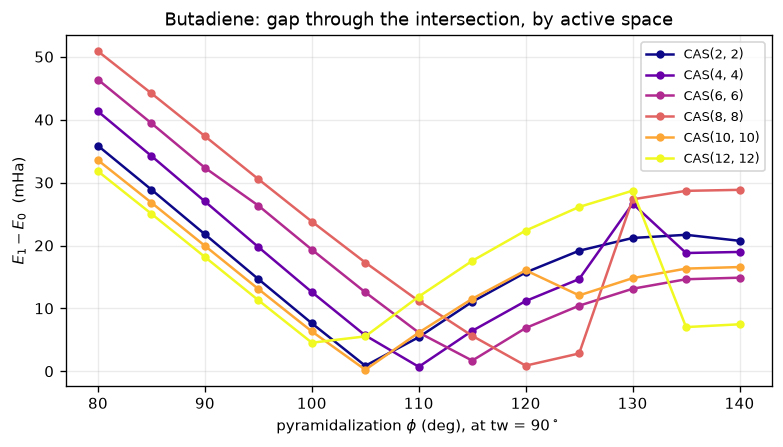

 active space  pyr (refined)     tw  vs largest rung  grid min (mHa)
----------------------------------------------------------------------
    CAS(2, 2)         105.49     90            +3.63           0.882
    CAS(4, 4)         109.83     90            +7.98           0.724
    CAS(6, 6)         114.81     90           +12.96           6.162
    CAS(8, 8)         121.05     90           +19.20           0.906
  CAS(10, 10)         105.04     90            +3.19           0.255
  CAS(12, 12)         101.85     90            +0.00           4.555

Largest rung available: CAS(12, 12). With no exact reference, the only
meaningful question is whether successive rungs still disagree.


In [3]:
if have:
    fig, ax = plt.subplots(figsize=(6.6, 3.8))
    cmap = plt.get_cmap("plasma")
    pos = {}
    for k, cas in enumerate(have):
        r = buta[cas]
        i = int(np.unravel_index(np.nanargmin(r.gap), r.gap.shape)[0])
        pos[cas] = buta_refined_pyr(r)
        ax.plot(r.phis, r.gap[i] * 1e3, "o-", ms=4,
                color=cmap(k / max(len(have) - 1, 1)), label=f"CAS{cas}")
    ax.set_xlabel(r"pyramidalization $\phi$ (deg), at tw = 90$^\circ$")
    ax.set_ylabel(r"$E_1 - E_0$  (mHa)")
    ax.set_title("Butadiene: gap through the intersection, by active space")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

    largest = have[-1]
    ref_pyr = pos[largest][0]
    print(f"{'active space':>13} {'pyr (refined)':>14} {'tw':>6} "
          f"{'vs largest rung':>16} {'grid min (mHa)':>15}")
    print("-" * 70)
    for cas in have:
        pyr, tw = pos[cas]
        print(f"{'CAS%s' % (cas,):>13} {pyr:14.2f} {tw:6.0f} {pyr - ref_pyr:+16.2f} "
              f"{buta[cas].min_gap_point()[2]*1e3:15.3f}")
    print(f"\nLargest rung available: CAS{largest}. With no exact reference, the only")
    print("meaningful question is whether successive rungs still disagree.")

### The comparator maps, and the loops they are being asked about

Same presentation as the ethylene ladder. The scanned window is `tw` in [70, 110], `pyr` in
[80, 140]; the two control loops sit at `tw` = 60 and 120 and therefore fall **outside** it, so
the axes are widened to show where they are and the colour map is drawn only where data exists.

White circle: that rung's own intersection. Black cross: the reference CAS(12,12) position, which
is also the centre of `B_x`. The panels make the 19&deg; scatter visible directly &mdash; and show
CAS(8,8)'s circle sitting outside the `B_x` ellipse.

CAS(12,12) has no panel: it was scanned on the single `tw = 90` row to keep its cost bounded
(>2.4 min per point), so there is no two-dimensional map for it &mdash; only the position marked
by the cross.

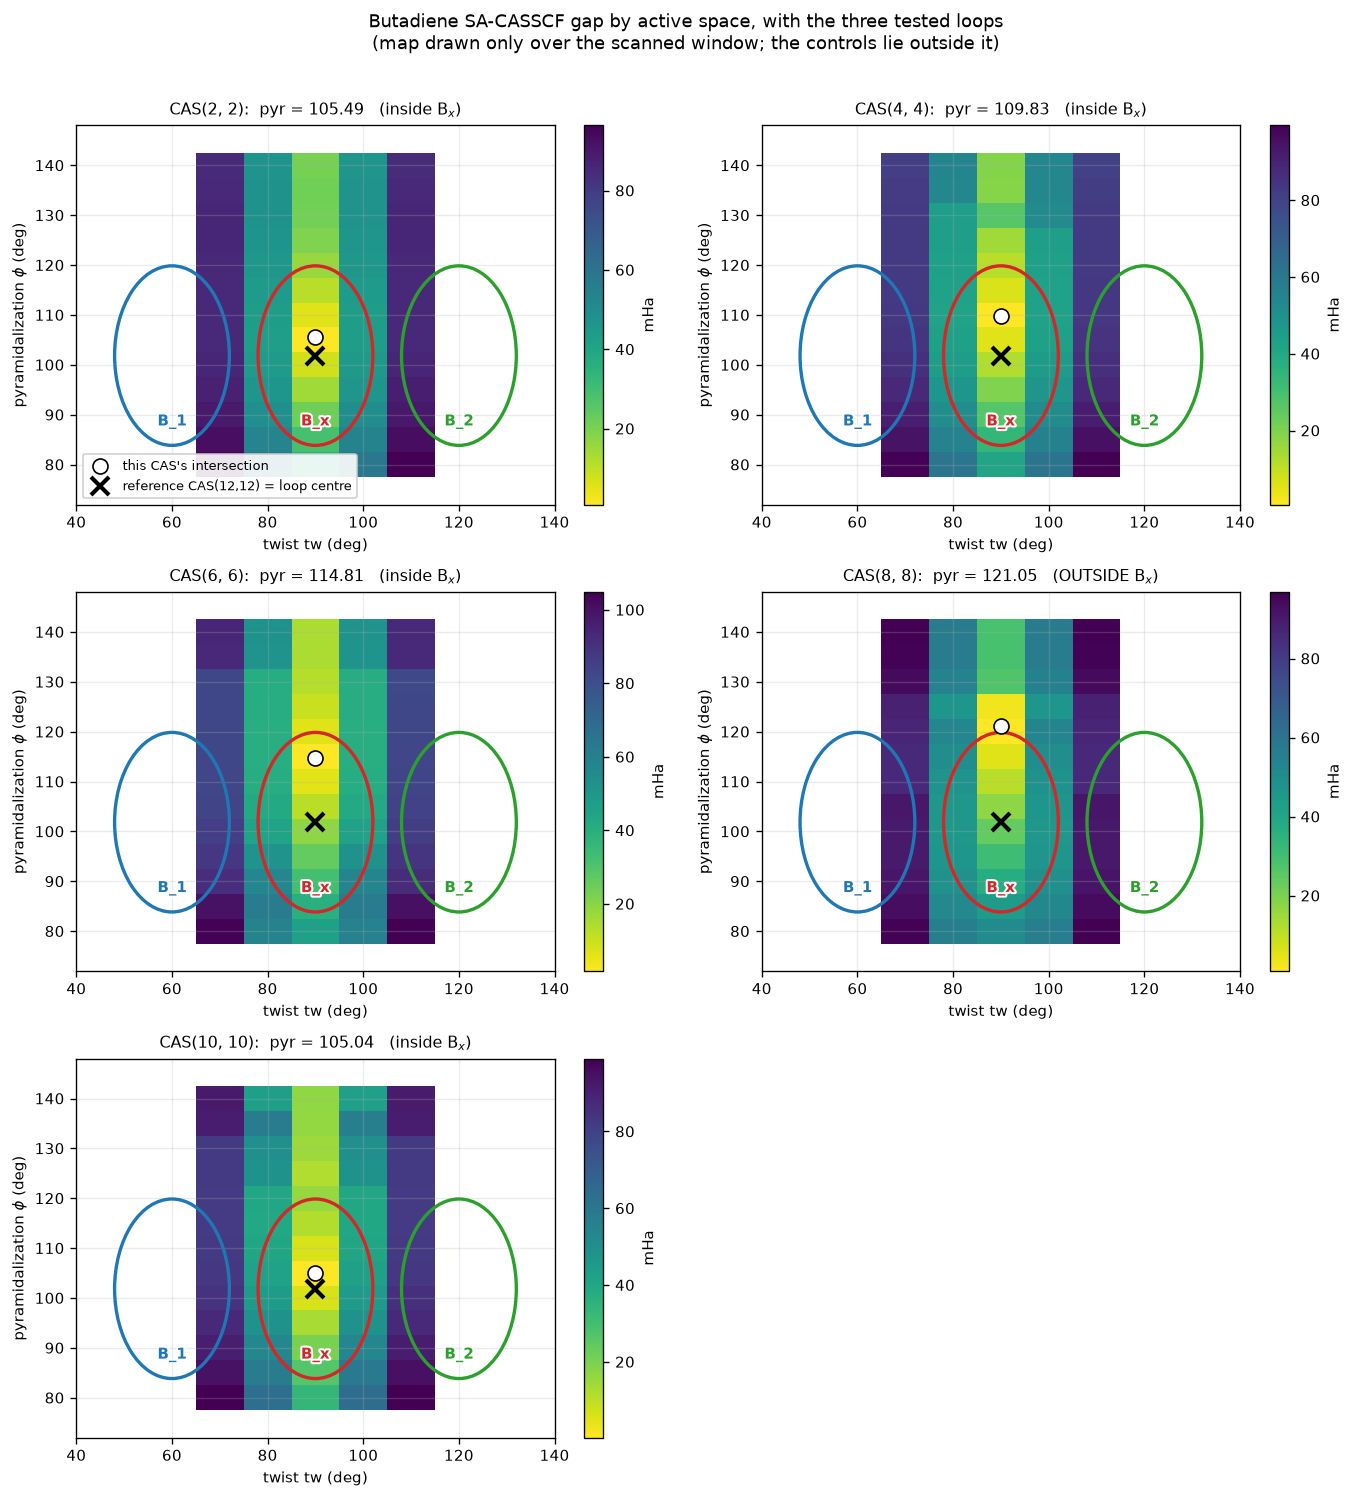

In [4]:
import matplotlib.patheffects as pe
OUTLINE = [pe.withStroke(linewidth=2.5, foreground="white")]

two_d = [c for c in have if buta[c].alphas.size > 1]
if two_d:
    B_CENTRE = (90.0, buta_refined_pyr(buta[have[-1]])[0])
    B_RADIUS = (12.0, 18.0)
    B_LOOPS = {
        "B_x": (B_CENTRE[0], B_CENTRE[1], "tab:red"),
        "B_1": (B_CENTRE[0] - 2.5 * B_RADIUS[0], B_CENTRE[1], "tab:blue"),
        "B_2": (B_CENTRE[0] + 2.5 * B_RADIUS[0], B_CENTRE[1], "tab:green"),
    }
    ncol = 2
    nrow = int(np.ceil(len(two_d) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(11.5, 4.1 * nrow), squeeze=False)
    for k, cas in enumerate(two_d):
        ax = axes[k // ncol][k % ncol]
        r = buta[cas]
        T, P = np.meshgrid(r.alphas, r.phis, indexing="ij")
        pcm = ax.pcolormesh(T, P, r.gap * 1e3, shading="nearest", cmap="viridis_r")
        fig.colorbar(pcm, ax=ax, label="mHa")
        for name, (ct, cp, col) in B_LOOPS.items():
            ax.add_patch(Ellipse((ct, cp), 2 * B_RADIUS[0], 2 * B_RADIUS[1], fill=False,
                                 lw=2.0, ec=col, zorder=5))
            # label inside the bottom of each ellipse, clear of the markers above
            ax.text(ct, cp - B_RADIUS[1] + 4, name, color=col, ha="center",
                    fontweight="bold", fontsize=9, zorder=6, path_effects=OUTLINE)
        pyr_here, tw_here = buta_refined_pyr(r)
        ax.plot(tw_here, pyr_here, "wo", ms=9, mec="k", zorder=7,
                label="this CAS's intersection")
        ax.plot(B_CENTRE[0], B_CENTRE[1], "kx", ms=11, mew=2.5, zorder=7,
                label="reference CAS(12,12) = loop centre")
        if k == 0:
            ax.legend(loc="lower left", fontsize=7.5, framealpha=0.9)
        inside = abs(pyr_here - B_CENTRE[1]) <= B_RADIUS[1]
        ax.set_title(f"CAS{cas}:  pyr = {pyr_here:.2f}   "
                     f"({'inside' if inside else 'OUTSIDE'} B$_x$)", fontsize=9.5)
        ax.set_xlabel("twist tw (deg)"); ax.set_ylabel(r"pyramidalization $\phi$ (deg)")
        ax.set_xlim(40, 140); ax.set_ylim(72, 148)
    for k in range(len(two_d), nrow * ncol):
        axes[k // ncol][k % ncol].set_visible(False)
    fig.suptitle("Butadiene SA-CASSCF gap by active space, with the three tested loops\n"
                 "(map drawn only over the scanned window; the controls lie outside it)",
                 y=1.01)
    plt.tight_layout(); plt.show()
else:
    print("No two-dimensional butadiene scans available.")

### Does the Berry phase survive this?

On formaldimine and ethylene the Berry phase was immune to the errors that defeated the
comparator, because every active space still placed the intersection *inside* the loop. Butadiene
looks like it should break that: the loops are centred on the CAS(12,12) intersection with an
18&deg; radius in `pyr`, and CAS(8,8) puts its intersection 19.2&deg; away &mdash; outside. The
natural prediction is that CAS(8,8) reports a **trivial** phase while the others report &pi;.

**It does not. Every rung returns &pi;.** The prediction was wrong, and its failure is the most
informative result here, so it is worth being explicit about what was assumed.

The assumption was that *the state-averaged gap minimum is the point the Berry phase encircles*.
It is not. The Berry phase transports the **state-specific** CASSCF ground state, whose
degeneracy sits wherever the state-specific surfaces touch; the scan minimum is computed with
**state-averaged** orbitals, a different set. For a converged active space the two coincide. For
a truncated one they need not &mdash; and for butadiene they do not.

This is not a grid artifact: refining CAS(8,8) on a 2&deg; grid puts its state-averaged minimum
at `pyr = 121.20`, a displacement of 19.35&deg;, genuinely outside the loop.

Shrinking the loop bounds the degeneracy the Berry phase *does* encircle. A 12&deg; loop reaching
only to `pyr = 113.9` still returns a clean &pi; (min overlap 0.87), so whatever carries the phase
lies **below 113.9, not at 121.2**. Loops of 8&deg; trend to the same sign but their adjacent
overlaps collapse to 0.24&ndash;0.77 &mdash; what a loop passing close to a degeneracy looks like
&mdash; and the continuity check refuses them rather than reporting a phase, which is the intended
behaviour.

In [5]:
if have:
    ref_pyr_b = buta_refined_pyr(buta[have[-1]])[0]
    print(f"{'CAS':>11} {'its own pyr':>12} {'displacement':>13} {'inside 18 deg?':>15}")
    print("-" * 56)
    for cas in have:
        pyr = buta_refined_pyr(buta[cas])[0]
        d = abs(pyr - ref_pyr_b)
        print(f"{'CAS%s' % (cas,):>11} {pyr:12.2f} {d:13.2f} {('yes' if d <= 18 else 'NO'):>15}")

buta_rows = berry_table(load_berry_records(BUTA))
if buta_rows:
    print()
    print(format_table(buta_rows, ["loop", "CAS", "N", "product", "endpoint",
                                   "min|ovl|", "phase", "status"]))
else:
    print("\nNo butadiene Berry records yet "
          "(python examples/run_butadiene_study.py berry).")

        CAS  its own pyr  displacement  inside 18 deg?
--------------------------------------------------------
  CAS(2, 2)       105.49          3.63             yes
  CAS(4, 4)       109.83          7.98             yes
  CAS(6, 6)       114.81         12.96             yes
  CAS(8, 8)       121.05         19.20              NO
CAS(10, 10)       105.04          3.19             yes
CAS(12, 12)       101.85          0.00             yes

loop  CAS         N   product  endpoint  min|ovl|  phase             status
----  ----------  --  -------  --------  --------  ----------------  ------
B_1   CAS(10,10)  13  +0.8676  +1.0000   +0.9860   trivial (0)       OK    
B_1   CAS(10,10)  21  +0.9143  +1.0000   +0.9945   trivial (0)       OK    
B_1   CAS(12,12)  13  +0.8679  +1.0000   +0.9860   trivial (0)       OK    
B_1   CAS(12,12)  21  +0.9146  +1.0000   +0.9946   trivial (0)       OK    
B_1   CAS(12,12)  31  +0.9409  +1.0000   +0.9975   trivial (0)       OK    
B_1   CAS(2,2)    13  +0.

## Drift of the intersection position with active space

The picture the study comes down to. Positions come from fitting `gap`&sup2;, which is exactly a
parabola for any cut through a cone, rather than fitting a parabola to the gap itself &mdash; the
gap is a V near an intersection, and a parabola through three points of a V is dragged toward the
grid minimum. Faint markers are the old, biased estimates, so the size of that correction is
visible rather than asserted.

For butadiene the shaded band is the extent of the enclosing loop `B_x` in `pyr`. A rung whose
marker falls outside the band places its **gap-scan** intersection outside the loop it is being
asked about.

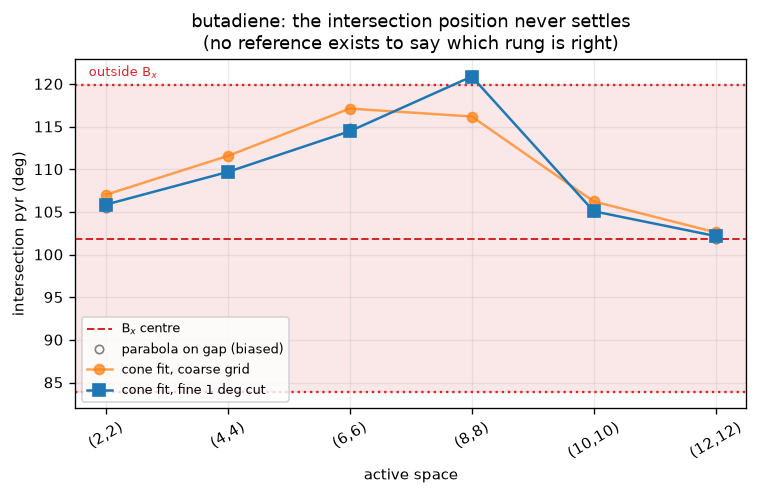

spread of the fine-cut positions across the ladder: 18.7 deg
top two rungs differ by 2.90 deg (ethylene met a 2 deg tolerance from CAS(10,10))


In [6]:
from berrycasscf.refine import cone_apex, parabolic_apex

def fine_position(ne, ncas):
    p = os.path.join(BUTA, f"butadiene_refinepyr_cas{ne}-{ncas}.npz")
    if os.path.exists(p):
        r = ScanResult.load(p)
        if np.isfinite(r.e_states).all():
            return cone_apex(r.phis, r.gap[0] * 1e3, window=None)
    return None

def coarse_positions(scan):
    i = int(np.unravel_index(np.nanargmin(scan.gap), scan.gap.shape)[0])
    x, g = scan.phis, scan.gap[i] * 1e3
    return cone_apex(x, g, window=3), parabolic_apex(x, g)

fig, ax = plt.subplots(figsize=(6.4, 4.2))

xs, cone_y, para_y, fine_y = [], [], [], []
for k, cas in enumerate(BUTA_LADDER):
    r = buta.get(cas)
    if r is None:
        continue
    c, pp = coarse_positions(r)
    f = fine_position(*cas)
    xs.append(k); cone_y.append(c.position); para_y.append(pp.position)
    fine_y.append(f.position if f is not None else np.nan)
if xs:
    lo, hi = 101.85 - 18.0, 101.85 + 18.0
    ax.axhspan(lo, hi, color="tab:red", alpha=0.10)
    ax.axhline(101.85, color="tab:red", ls="--", lw=1.2, label="B$_x$ centre")
    for edge in (lo, hi):
        ax.axhline(edge, color="tab:red", ls=":", lw=1.4)
    ax.text(0.02, hi + 0.6, "outside B$_x$", color="tab:red", fontsize=8,
            transform=ax.get_yaxis_transform(), va="bottom")
    ax.plot(xs, para_y, "o", ms=5, mfc="none", color="grey", label="parabola on gap (biased)")
    ax.plot(xs, cone_y, "o-", ms=6, color="tab:orange", alpha=0.7, label="cone fit, coarse grid")
    if np.isfinite(fine_y).any():
        ax.plot(xs, fine_y, "s-", ms=7, color="tab:blue", label="cone fit, fine 1 deg cut")
ax.set_xticks(range(len(BUTA_LADDER)))
ax.set_xticklabels([f"({a},{b})" for a, b in BUTA_LADDER], rotation=30)
ax.set_xlabel("active space"); ax.set_ylabel("intersection pyr (deg)")
ax.set_title("butadiene: the intersection position never settles\n"
             "(no reference exists to say which rung is right)")
ax.legend(fontsize=7.5)
plt.tight_layout(); plt.show()

if xs:
    span = np.nanmax(fine_y) - np.nanmin(fine_y) if np.isfinite(fine_y).any() else np.nan
    print(f"spread of the fine-cut positions across the ladder: {span:.1f} deg")
    print(f"top two rungs differ by {abs(fine_y[-1] - fine_y[-2]):.2f} deg "
          f"(ethylene met a 2 deg tolerance from CAS(10,10))")

## The fitted positions are good; the fitted *gaps* are not

Every position above comes from a cone fit along a one-dimensional cut, which assumes the cut
passes through the apex. That assumption is testable: seed a derivative-free 2D minimization of
the gap from each fitted position and see how far it moves and how far the gap falls
(`examples/run_gap_minimum_search.py`, cold SA-CASSCF evaluations, cached, hard budget).

This matters because a "closest approach" read off a fit was once taken as evidence that a rung
had only an avoided crossing rather than a true intersection. That inference was wrong for five
of the six rungs.

       CAS     fitted (tw, pyr)   fit gap   searched (tw, pyr)       gap   moved  evals     fall
------------------------------------------------------------------------------------------------
  CAS(2,2) ( 90.00, 105.86)    0.2755 ( 89.97, 105.67)    0.0032   0.190     40      87x
  CAS(4,4) ( 90.00, 109.68)    0.3414 ( 89.98, 109.41)    0.0045   0.270     40      76x
  CAS(6,6) ( 90.00, 114.46)    0.9897 ( 89.11, 114.61)    0.0061   0.905     40     163x
  CAS(8,8) ( 90.00, 120.87)    0.2011 ( 89.98, 121.08)    0.0026   0.216     40      76x
CAS(10,10) ( 90.00, 105.07)    0.3027 ( 89.96, 104.90)    0.0064   0.179     40      47x
CAS(12,12) ( 90.00, 102.17)    1.7758 ( 89.97, 101.94)    1.4595   0.228     58       1x


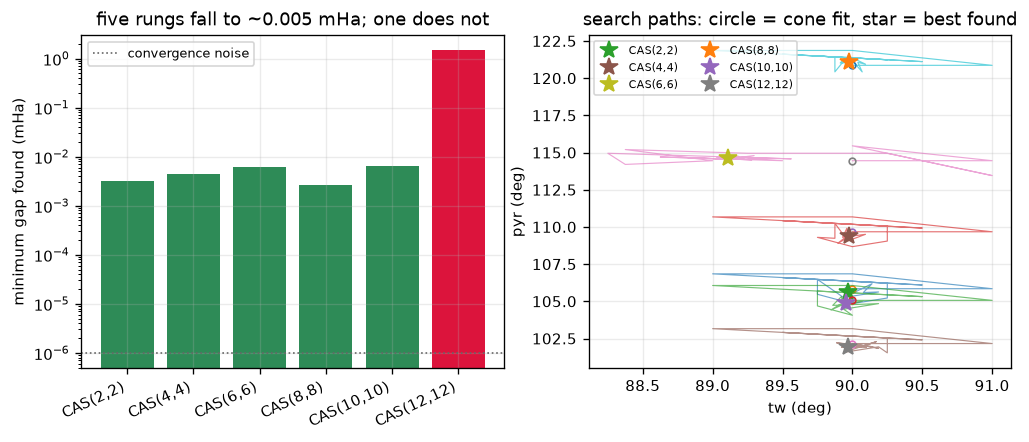


NOTE: no rung's search converged in the optimizer's sense -- each stops on its
evaluation budget, a CAS(12,12) evaluation costing ~2.2 minutes. The budgets are
comparable (40 for the light rungs, 60 for CAS(12,12)), and CAS(12,12) was given
the LARGER one deliberately: an earlier 30-evaluation run returned 1.4963 mHa, so
doubling the effort moved the answer by 2.5%. The contrast is not a budget artifact.


In [7]:
gm = os.path.join(BUTA, "gap_minimum_search.json")
if os.path.exists(gm):
    runs = sorted(json.load(open(gm))["runs"], key=lambda r: r["cas"])
    print(f"{'CAS':>10} {'fitted (tw, pyr)':>20} {'fit gap':>9} "
          f"{'searched (tw, pyr)':>20} {'gap':>9} {'moved':>7} {'evals':>6} {'fall':>8}")
    print("-" * 96)
    labels, found = [], []
    for r in runs:
        lab = "CAS(%d,%d)" % tuple(r["cas"])
        fall = r["start_gap"] / r["gap"] if r["gap"] else float("nan")
        print(f"{lab:>10} ({r['start'][0]:6.2f},{r['start'][1]:7.2f}) "
              f"{r['start_gap']:9.4f} ({r['found'][0]:6.2f},{r['found'][1]:7.2f}) "
              f"{r['gap']:9.4f} {r['moved']:7.3f} {r['n_evaluations']:6d} {fall:7.0f}x")
        labels.append(lab); found.append(r["gap"])

    fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.6))
    ax = axes[0]
    ax.bar(range(len(labels)), found,
           color=["crimson" if g > 0.1 else "seagreen" for g in found])
    ax.set_yscale("log"); ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=25, ha="right")
    ax.axhline(1e-6, color="0.4", ls=":", lw=1, label="convergence noise")
    ax.set_ylabel("minimum gap found (mHa)")
    ax.set_title("five rungs fall to ~0.005 mHa; one does not")
    ax.legend(fontsize=7.5)

    # the search paths, to show it is a real 2D search and not a line fit
    ax = axes[1]
    for r in runs:
        tr = np.array(r["trace"])
        lab = "CAS(%d,%d)" % tuple(r["cas"])
        ax.plot(tr[:, 0], tr[:, 1], "-", lw=0.7, alpha=0.65)
        ax.plot(r["start"][0], r["start"][1], "o", ms=4, mfc="none")
        ax.plot(r["found"][0], r["found"][1], "*", ms=11, label=lab)
    ax.set_xlabel("tw (deg)"); ax.set_ylabel("pyr (deg)")
    ax.set_title("search paths: circle = cone fit, star = best found")
    ax.legend(fontsize=6.5, ncol=2)
    plt.show()

    print()
    print("NOTE: no rung's search converged in the optimizer's sense -- each stops on its")
    print("evaluation budget, a CAS(12,12) evaluation costing ~2.2 minutes. The budgets are")
    print("comparable (40 for the light rungs, 60 for CAS(12,12)), and CAS(12,12) was given")
    print("the LARGER one deliberately: an earlier 30-evaluation run returned 1.4963 mHa, so")
    print("doubling the effort moved the answer by 2.5%. The contrast is not a budget artifact.")
else:
    print("Not yet run:  python examples/run_gap_minimum_search.py")

Three results, one of which corrects an earlier claim in this project.

1. **The fitted positions are good to ~0.2&deg;** &mdash; except CAS(6,6), which moves 0.91&deg;.
   The 19.2&deg; spread of the ladder is therefore not a fitting artifact.
2. **The fitted closest approach overestimates by about two orders of magnitude, wherever an
   intersection exists.** CAS(2,2) through CAS(10,10) all reach 0.003&ndash;0.006 mHa against
   fitted values of 0.2&ndash;1.0 mHa. Those rungs **do** contain a genuine conical intersection in
   this plane. A fit constrained to a line through an assumed position cannot do better than that
   line allows.
3. **CAS(6,6)'s intersection sits at `tw` = 89.11, not 90.** That is why its `pyr` cut fitted badly
   and appeared to jump: the cut missed the apex. The one-dimensional `tw` check reported 89.98 and
   did not catch it, because that cut was taken at the wrong `pyr`. *Two one-dimensional cuts
   through a two-dimensional surface are not a substitute for a search.*

**CAS(12,12) is the exception, and it is not a fitting artifact**: the same search improves the gap
by only 18%, to 1.4595 mHa, using 58 evaluations -- more than the 40 given to every other rung.
Doubling the budget from 30 to 58 moved the answer by 2.5%, so it is not an artifact of stopping
early either.

### What does a 1.5 mHa floor mean? Not what it first seemed

It is tempting to read that as "no conical intersection in this plane at CAS(12,12)", and an
earlier version of this project's write-up did. **That over-reads it.** 1.5 mHa is 0.04 eV,
comfortably inside the error of the model itself &mdash; 6-31G\*, a truncated active space, no
dynamic correlation &mdash; so a surface that genuinely touches could easily present a floor that
size here.

What survives is a **relative** statement: the same search drives every other rung to
0.003&ndash;0.006 mHa and this one only to 1.5, some 300x higher. Deciding the absolute question
needs a criterion for when a state-averaged minimum gap is compatible with a true crossing &mdash;
some combination of an absolute tolerance and the local cone slopes, which here are ~1.3 mHa/deg
&mdash; and no such criterion has been established. The honest description is *"reasonably small,
and unusually large relative to the other rungs"*.

## Does it fail loudly?

A method that returns a wrong answer confidently is worse than one that refuses. This probes the
refusal behaviour at CAS(8,8), shrinking the loop toward the degeneracy and varying the
discretization independently.

The figure is built so it *can* embarrass the method. Hollow markers were **refused**; the
annotation records what the worst of them would have reported. A refused run whose sign agrees
with the well-resolved ones is a **cost** of the conservatism, not a save, and is counted as such.

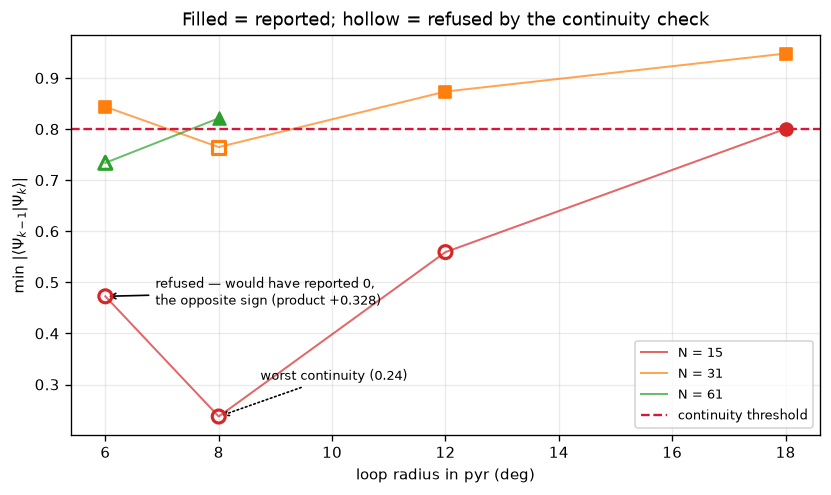

 radius    N  min|ovl|   product  outcome
--------------------------------------------------------
control   15     0.946   +0.7630  reported trivial
control   31     0.987   +0.8761  reported trivial
      6   15     0.473   +0.3283  REFUSED (would say 0)
      6   31     0.844   -0.5535  reported non-trivial
      6   61     0.734   +0.5731  REFUSED (would say 0)
      8   15     0.237   -0.1764  REFUSED (would say pi)
      8   31     0.765   -0.5189  REFUSED (would say pi)
      8   61     0.821   -0.6610  reported non-trivial
     12   15     0.559   -0.4021  REFUSED (would say pi)
     12   31     0.874   -0.6544  reported non-trivial
     18   15     0.801   -0.5366  reported non-trivial
     18   31     0.948   -0.7369  reported non-trivial

5 of 12 refused; 3 of those would have given the same sign as the well-resolved runs — the price of erring toward refusal.


In [8]:
fm_path = os.path.join(BUTA, "failure_modes.json")
if os.path.exists(fm_path):
    fm = json.load(open(fm_path))
    runs = [r for r in fm["runs"] if r["kind"] == "enclosing"]
    fig, ax = plt.subplots(figsize=(7.0, 4.2))
    for n, mk, col in [(15, "o", "tab:red"), (31, "s", "tab:orange"), (61, "^", "tab:green")]:
        sub = sorted([r for r in runs if r["n_points"] == n], key=lambda d: d["radius_pyr"])
        if not sub:
            continue
        xr = [r["radius_pyr"] for r in sub]
        yo = [r["min_abs_overlap"] for r in sub]
        ok = [r["status"] == "OK" for r in sub]
        ax.plot(xr, yo, "-", color=col, lw=1.2, alpha=0.7, label=f"N = {n}")
        ax.scatter([x for x, o in zip(xr, ok) if o], [y for y, o in zip(yo, ok) if o],
                   marker=mk, s=60, color=col, zorder=5)
        ax.scatter([x for x, o in zip(xr, ok) if not o], [y for y, o in zip(yo, ok) if not o],
                   marker=mk, s=60, facecolors="none", edgecolors=col, linewidths=1.9, zorder=5)
    ax.axhline(0.80, color="crimson", ls="--", lw=1.4, label="continuity threshold")
    # Annotate the refused run that would have given the WRONG sign -- more telling than the
    # one with the lowest overlap, which would merely have been imprecise.
    consensus = "pi"
    wrong = [r for r in runs if r["status"] != "OK" and r["would_have_said"] != consensus]
    if wrong:
        w = min(wrong, key=lambda r: r["min_abs_overlap"])
        ax.annotate(f"refused — would have reported {w['would_have_said']},\n"
                    f"the opposite sign (product {w['product']:+.3f})",
                    (w["radius_pyr"], w["min_abs_overlap"]),
                    xytext=(30, -5), textcoords="offset points", fontsize=8,
                    arrowprops=dict(arrowstyle="->", lw=1))
    worst = min(runs, key=lambda r: r["min_abs_overlap"])
    ax.annotate(f"worst continuity ({worst['min_abs_overlap']:.2f})",
                (worst["radius_pyr"], worst["min_abs_overlap"]),
                xytext=(25, 22), textcoords="offset points", fontsize=8,
                arrowprops=dict(arrowstyle="->", lw=1, ls=":"))
    ax.set_xlabel("loop radius in pyr (deg)")
    ax.set_ylabel(r"min $|\langle\Psi_{k-1}|\Psi_k\rangle|$")
    ax.set_title("Filled = reported; hollow = refused by the continuity check")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

    print(f"{'radius':>7} {'N':>4} {'min|ovl|':>9} {'product':>9}  outcome")
    print("-" * 56)
    for r in sorted(fm["runs"], key=lambda d: (d["kind"], d["radius_pyr"], d["n_points"])):
        tag = "control" if r["kind"] != "enclosing" else f"{r['radius_pyr']:.0f}"
        out = ("reported " + r["phase"].split()[0]) if r["status"] == "OK" \
              else f"REFUSED (would say {r['would_have_said']})"
        print(f"{tag:>7} {r['n_points']:>4} {r['min_abs_overlap']:9.3f} "
              f"{r['product']:+9.4f}  {out}")

    refused = [r for r in fm["runs"] if r["status"] != "OK"]
    same = [r for r in refused if r["would_have_said"] == "pi"]
    print(f"\n{len(refused)} of {len(fm['runs'])} refused; {len(same)} of those would have given "
          "the same sign as the well-resolved runs — the price of erring toward refusal.")
else:
    print("Run: python examples/run_failure_modes.py")

Three things this establishes, and one it undermines.

* **It catches wrong answers, not just imprecise ones.** Radius 6 at N=15 would have reported a
  confident **trivial** verdict (+0.328), the opposite of every well-resolved loop. Refused.
* **It separates "too coarse" from "too close".** Radius 8 is refused at N=15 and N=31, but its
  sign never wavers (&minus;0.18, &minus;0.52, &minus;0.66) and it passes at N=61 &mdash; a pure
  discretization problem. Radius 6's sign *flips* (+0.33, &minus;0.55, +0.57) and it never passes
  twice.
* **It refuses lost continuity, not proximity.** The displaced control encloses nothing but runs
  close to the seam, and sails through at overlaps 0.95&ndash;0.99 with the correct trivial phase.

And the undermining: **radius 6 at N=31 passed every per-run check while its neighbours
contradict it.** It reported &pi; at overlap 0.844; N=15 and N=61 both say 0 &mdash; though both of
those were themselves refused, so their signs carry little weight either. The defensible statement
is that **radius 6 is marginal: its Berry phase is not determined by these calculations.**

There *was* evidence against it, and it was not being used. That run carries a *"continuation chain
broken"* message: the solver's fallback ladder fell through to a **cold start** mid-loop, so that
point was never reached by continuation at all. Gauge fixing repairs a cold start's arbitrary sign
but not a change of *branch*, and a modest branch change still clears a 0.80 overlap threshold.
It was reported as a warning rather than acted on.

**That is now a binding check**, and it was chosen by calibration rather than taste. Re-deciding
all 116 saved runs under candidate thresholds (`examples/calibrate_thresholds.py`) scores them by
self-consistency: runs of the same loop and active space at different N must agree, since physics
does not depend on N. With the chain check off, an overlap threshold of 0.80 admits this lone
dissenter and 0.70 admits an outright contradiction; the threshold has to reach 0.86 to be safe,
costing five otherwise-decidable questions. With the chain check on, **no threshold from 0.70 to
0.92 admits either failure mode**, at a cost of one. The danger was never the overlap threshold.

## Where does loop transport think the intersection is?

The comparison so far has been phase-against-position: loop transport answers "yes, enclosed" while
the gap scan answers "here". They can be compared on the same footing by making loop transport
produce a position too &mdash; bisecting the loop radius about fixed centres until the phase turns
over, then intersecting the results (`locating_intersections.ipynb` explains the construction).

Six rungs of that, and the table below is the point of this notebook.

In [9]:
import json, os
CENTRE = (90.0, 101.85321091497578)      # the B_x centre, and centre 1 of every bisection
SHAPE = (12.0, 18.0)                     # the B_x semi-axes

def gap_scan_pyr(ne):
    gm = os.path.join(ROOT, "results", "butadiene", "gap_minimum_search.json")
    for r in json.load(open(gm))["runs"]:
        if tuple(r["cas"]) == (ne, ne):
            return r["found"][1]
    return None

rows = []
for ne in (2, 4, 6, 8, 10, 12):
    p = os.path.join(ROOT, "results", "localize", f"butadiene_cas{ne}-{ne}.json")
    if not os.path.exists(p):
        rows.append({"cas": ne, "rho": None, "unc": None, "tri": None, "n": 0,
                     "gap": gap_scan_pyr(ne)})
        continue
    d = json.load(open(p))
    b0 = d["bisections"][0]
    rows.append({"cas": ne, "rho": b0.get("rho"), "unc": b0.get("rho_uncertainty"),
                 "tri": (d.get("triangulation") or {}).get("chosen"),
                 "n": sum(1 for x in d["bisections"] if x.get("rho") is not None),
                 "gap": gap_scan_pyr(ne)})

print(f"{'CAS':>8} {'rho about the B_x centre':>25} {'implied pyr*':>13} {'triangulated':>20} "
      f"{'gap scan':>10} {'difference':>11}")
print("-" * 92)
for r in rows:
    if r["rho"] is None:
        print(f"{('(%d,%d)' % (r['cas'], r['cas'])):>8} {'not measured':>25} {'':>13} {'':>20} "
              f"{r['gap']:>10.2f}")
        continue
    imp = CENTRE[1] + r["rho"] * SHAPE[1]
    tri = f"({r['tri'][0]:.2f}, {r['tri'][1]:.2f})" if r["tri"] else f"{r['n']}/3 centres"
    print(f"{('(%d,%d)' % (r['cas'], r['cas'])):>8} "
          f"{('%.4f +- %.4f' % (r['rho'], r['unc'])):>25} {imp:>13.2f} {tri:>20} "
          f"{r['gap']:>10.2f} {imp - r['gap']:>+11.2f}")
print("\n* implied pyr assumes the object lies on the tw = 90 line; the triangulations that")
print("  succeeded put it within ~1.2 deg of it, so the assumption is close but not exact.")

got = [CENTRE[1] + r["rho"] * SHAPE[1] for r in rows if r["rho"] is not None]
gaps = [r["gap"] for r in rows if r["rho"] is not None]
print(f"\nspread of loop-transport positions: {max(got) - min(got):5.1f} deg")
print(f"spread of gap-scan positions:       {max(gaps) - min(gaps):5.1f} deg")
print(f"top three rungs, loop transport:    {min(got[2:]):.2f} to {max(got[2:]):.2f} deg")

     CAS  rho about the B_x centre  implied pyr*         triangulated   gap scan  difference
--------------------------------------------------------------------------------------------
   (2,2)          0.5385 +- 0.0843        111.55          1/3 centres     105.67       +5.88
   (4,4)          0.7016 +- 0.0277        114.48          1/3 centres     109.41       +5.07
   (6,6)          0.2367 +- 0.0461        106.11      (91.18, 105.73)     114.61       -8.50
   (8,8)          0.2367 +- 0.0461        106.11          1/3 centres     121.08      -14.97
 (10,10)          0.2820 +- 0.1058        106.93       (89.87, 96.78)     104.90       +2.03
 (12,12)              not measured                                        101.94

* implied pyr assumes the object lies on the tw = 90 line; the triangulations that
  succeeded put it within ~1.2 deg of it, so the assumption is close but not exact.

spread of loop-transport positions:   8.4 deg
spread of gap-scan positions:        16.2 deg
top thr

**Both methods move, and one moves much less.** Over the five rungs where both have an answer,
loop transport's positions span 8.4&deg; and the gap scan's 16.2&deg; &mdash; and the gap scan's full
six-rung spread, including the CAS(12,12) row that loop transport did not bracket, is 19.1&deg;.
From CAS(6,6) upward loop transport sits at 106&ndash;107&deg;
&mdash; a spread of under a degree over three rungs &mdash; while the gap scan over those same rungs
reports 114.6, 121.1 and 104.9.

**And they never coincide.** The last column is the disagreement, and it does not shrink with the
active space: +5.9, +5.1, &minus;8.5, &minus;15.0, +2.0. Both the size and the *sign* change.

This is the quantitative form of the phase result above. The topological answer was identical at
every rung; the position it implies is far steadier than the comparator's; and the two are measuring
objects that are several degrees apart at every active space. Which of them is right cannot be
settled here &mdash; butadiene has no exact reference &mdash; but §3 of `docs/findings.md` and
`probing_by_small_loops.ipynb` show the disagreement is real rather than a resolution artefact.

Two honesty notes. The bisections bracket to &plusmn;0.03&ndash;0.11 in &rho;, i.e. &plusmn;0.5&ndash;1.9&deg;
in `pyr`, so the +2.0&deg; row at CAS(10,10) is the one place where the two are within reach of each
other. And only two rungs triangulated cleanly: CAS(6,6) from three centres with a residual of
0.024, and CAS(10,10) from two, which leaves a mirror ambiguity between (89.87, 96.78) and
(89.87, 106.93) that nothing in that run resolves.

So the Berry phase returns the same answer &mdash; &pi; on the enclosing loop, 0 on both controls
&mdash; at every active space tested, while the state-averaged estimate of *where* the
intersection is scatters over 19&deg; and never settles. **The topological method is more stable
across the ladder than the quantity meant to validate it.**

That does not make it right by default: with no exact reference, "&pi; at every rung" could be
four consistent errors. But it is consistent, it passes every internal check, and it costs a
fraction of the comparator.

## What could have broken this, and what happened when it was checked

Every result above rests on assumptions that were cheap to state and easy to leave untested. These
were tested; three broke.

**Does the intersection really sit at `tw` = 90?** Assumed from a five-row grid, with *no symmetry
forcing it* for butadiene. Fine 1&deg; cuts say yes &mdash; 89.982 at CAS(6,6), 89.992 at CAS(8,8),
89.958 at CAS(12,12). The assumption survived.

**Is the CAS(6,6) cut a cone at all?** No. Re-sampled at 0.25&deg; it falls to 0.847 mHa at
pyr = 114.75 then *jumps* to 4.05 mHa one step later: a state-averaged CASSCF solution switch, not
cone structure. Its quoted position is a grid minimum, not a fit, and that rung is not evidence
about where a cone sits. The cone fit declines to model it rather than returning a number.

**Is the fitted "closest approach" meaningful?** Only if the cut is fine enough. On a 1&deg; grid
it is dominated by resolution: re-sampling at 0.25&deg; drops CAS(4,4) from 0.92 to **0.098 mHa**
and CAS(10,10) from 0.66 to **0.237 mHa**.

**Does loop transport agree with the gap scan at the reference rung?** Loop transport at
CAS(12,12) returns **&pi;**, stable at N = 13 and N = 21 (overlaps 0.83 and 0.88, endpoint
&minus;1.000000), while the gap scan finds no degeneracy on the cut it sampled (branches meeting
at ~1.7 mHa, against ~0.1&ndash;0.2 for CAS(4,4) and CAS(10,10)).

Read naively that is the two methods disagreeing about *whether anything is enclosed*. Two
objections were raised against that reading, and **both have now been tested**:

1. *The floor came from a fit along a line.* Fits of that kind run ~100x too high at every other
   rung (see the direct search above) &mdash; but a free 2D minimization from that position
   converged to **1.496 mHa**, only 16% below the fitted value. The floor is real.
2. *Only a cross through the loop was sampled* &mdash; one row at `tw` = 90, one column at
   `pyr` = 102.2 &mdash; while the loop spans `tw` 78&ndash;102 and `pyr` 83.9&ndash;119.9, so an
   intersection off that cross would produce exactly what was seen. The scan over the loop's
   *area* below settles it.

In [10]:
ls_path = sorted(glob.glob(os.path.join(BUTA, "butadiene_loopscan_cas12-12_*.npz")))
if ls_path:
    r = ScanResult.load(ls_path[-1])
    finished = bool(np.isfinite(r.e_states).all())
    if finished:
        t, pyr, g = r.min_gap_point()
        inside = (abs(t - 90.0) <= 12.0) and (abs(pyr - 101.85) <= 18.0)
        print(f"CAS(12,12) over the loop area ({r.alphas.size}x{r.phis.size} points):")
        print(f"  minimum gap {g*1e3:.3f} mHa at (tw = {t:.2f}, pyr = {pyr:.2f}); "
              f"inside B_x: {inside}\n")
        print("  gap (mHa), rows = tw, cols = pyr:")
        print("        " + " ".join(f"{v:7.1f}" for v in r.phis))
        for i, a_ in enumerate(r.alphas):
            print(f"  {a_:5.1f} " + " ".join(f"{v:7.3f}" for v in r.gap[i] * 1e3))
        print()
        if g * 1e3 < 1.0 and inside:
            print("  -> a degeneracy IS present inside the loop, off the sampled cross;")
            print("     loop transport's pi is consistent with the gap scan after all.")
        elif inside:
            print(f"  -> the smallest gap anywhere in the loop area is still {g*1e3:.2f} mHa,")
            print("     so no clear degeneracy was found inside the loop. That would leave the")
            print("     two methods genuinely at odds, and is the open question.")
    else:
        done = int(np.isfinite(r.e_states).all(axis=2).sum())
        print(f"loop-area scan in progress: {done}/{r.converged.size} points "
              "(tail -f logs/butadiene_loopscan_cas12-12.log)")
else:
    print("Not yet run:  python examples/run_butadiene_study.py loopscan --cas 12,12 --grid 5 5")

CAS(12,12) over the loop area (5x5 points):
  minimum gap 2.121 mHa at (tw = 90.00, pyr = 101.85); inside B_x: True

  gap (mHa), rows = tw, cols = pyr:
           83.8    92.8   101.8   110.8   119.8
   78.0  60.890  57.325  54.757  53.236  48.619
   84.0  38.201  30.888  28.071  30.799  36.341
   90.0  26.604  14.252   2.121  12.903  22.246
   96.0  38.538  31.312  28.532  31.054  36.429
  102.0  65.642  57.695  52.089  53.500  48.679

  -> the smallest gap anywhere in the loop area is still 2.12 mHa,
     so no clear degeneracy was found inside the loop. That would leave the
     two methods genuinely at odds, and is the open question.
